# Access Booms

    * Original Data Source: https://zenodo.org/records/15672978
    * Reference:  https://opensciencedata.esa.int/projects/booms/collection 
    * OSC entry: https://opensciencedata.esa.int/projects/booms/collection ,
    * License: CC-BY-NC-4.0

In [1]:
import xarray as xr

In [2]:
data_href1 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/booms/seascape-t1-owt.zarr/'
data_href2 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/booms/seascape-t2-biophysical.zarr/'
data_href3 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/booms/seascape-t3-4d-atlantic.zarr/'
data_href4 = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/booms/seascape-t3-4d-southern.zarr/'

In [3]:
ds = xr.open_zarr(data_href1)
ds

<xarray.Dataset> Size: 44GB
Dimensions:                             (time: 294, lat: 4320, lon: 8640)
Coordinates:
  * time                                (time) datetime64[ns] 2kB 1998-01-01 ...
  * lat                                 (lat) float64 35kB 89.98 ... -89.98
  * lon                                 (lon) float64 69kB -180.0 ... 180.0
Data variables:
    smoothed_mode_dominant_water_class  (time, lat, lon) float32 44GB dask.array<chunksize=(3, 2160, 4320), meta=np.ndarray>
Attributes:
    description:  seascape V1 for BOOMS
    history:      Wed Jun 14 17:14:50 2023: ncks -L 5 -O ./seascape-t1-owt/1m...
    NCO:          netCDF Operators version 5.0.6 (Homepage = http://nco.sf.ne...

### Plotting

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_med_water_class(da, label="smoothed mode dominant water class"):

    # 14 discrete OWT classes
    classes = np.arange(1, 15)

    # A categorical colour map
    cmap = plt.get_cmap("tab20", 14)

    # Boundaries put each integer in the centre of a colour bin
    boundaries = np.arange(0.5, 15.5, 1)
    norm = mcolors.BoundaryNorm(
        boundaries,
        ncolors=cmap.N
    )

    fig = plt.figure(figsize=(13, 7))

    ax = plt.axes(
        projection=ccrs.PlateCarree()
    )

    im = ax.pcolormesh(
        da.lon,
        da.lat,
        da,
        cmap=cmap,
        norm=norm,
        shading="nearest",
        transform=ccrs.PlateCarree()
    )

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgrey",
        zorder=2
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.6,
        zorder=3
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.3,
        zorder=3
    )

    cbar = plt.colorbar(
        im,
        ax=ax,
        ticks=classes,
        boundaries=boundaries,
        pad=0.03,
        shrink=0.85
    )

    cbar.set_label(label)

    date = da.time.values if "time" in da.coords else ds.time.isel(time=time_index).values

    ax.set_title(
        f"Bio-optical Seascape — Mediterranean\n"
        f"{np.datetime_as_string(date, unit='D')}"
    )

    plt.tight_layout()

    return fig, ax

(<Figure size 1300x700 with 2 Axes>,
 <GeoAxes: title={'center': 'Bio-optical Seascape — Mediterranean\n1998-01-01'}>)

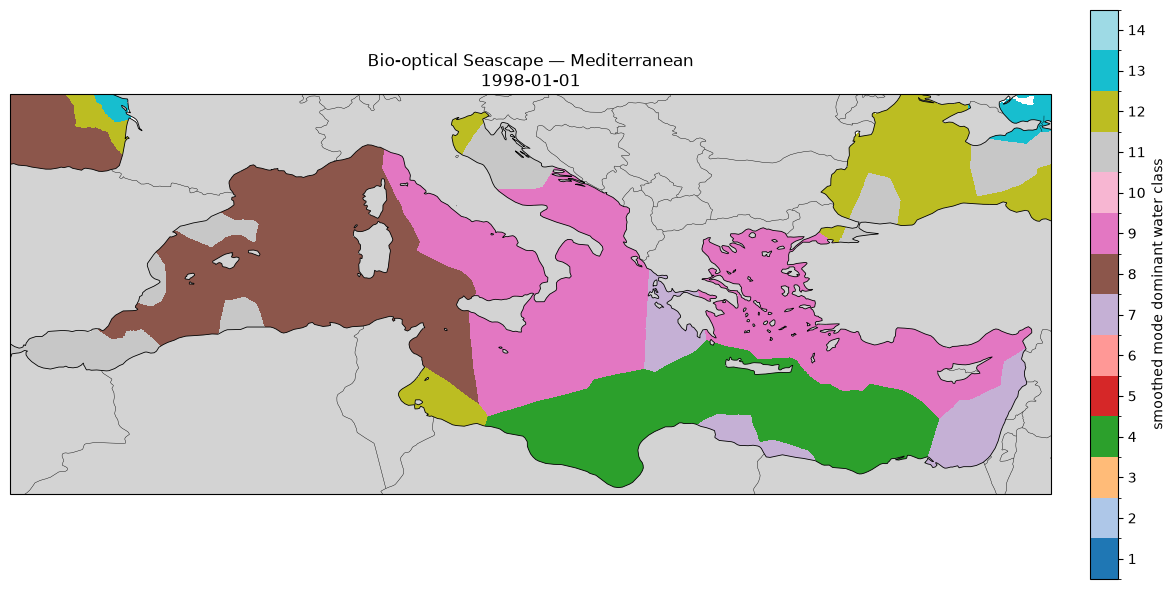

In [5]:
ds = xr.open_zarr(data_href1)

# subset data
da = ds['smoothed_mode_dominant_water_class'].isel(time=0)

# Mediterranean bounding box
lon_min, lon_max = -6, 37
lat_min, lat_max = 30, 46.5


# Crop before plotting
da = da.where(
    (da.lon >= lon_min) &
    (da.lon <= lon_max) &
    (da.lat >= lat_min) &
    (da.lat <= lat_max),
    drop=True
)

plot_med_water_class(da)

(<Figure size 1300x700 with 2 Axes>,
 <GeoAxes: title={'center': 'Bio-optical Seascape — Mediterranean\n1999-01-01'}>)

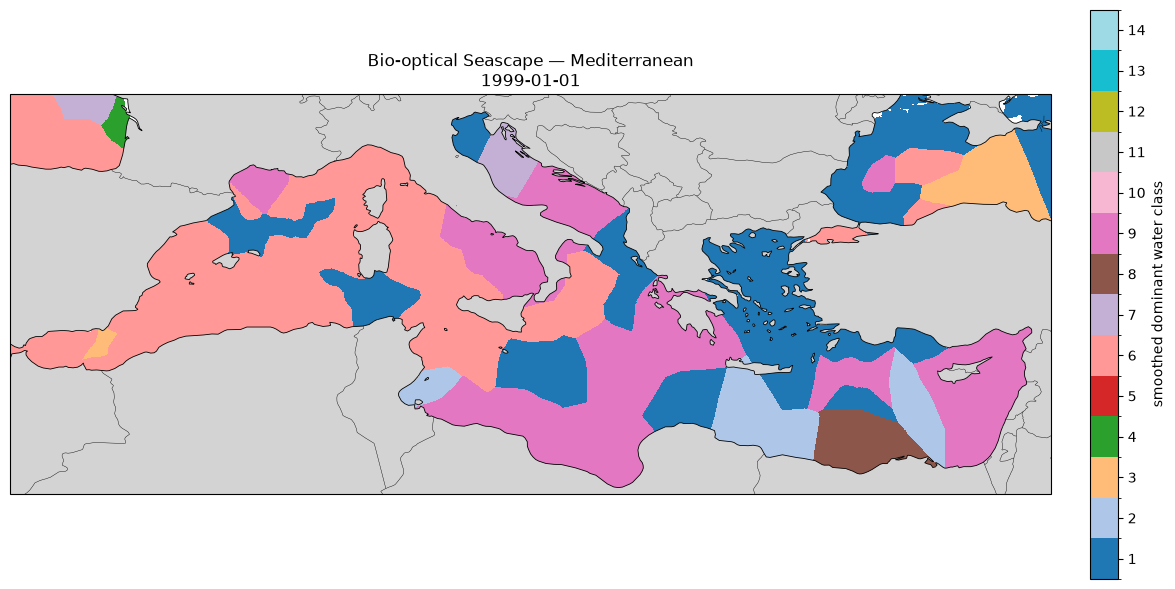

In [6]:
ds = xr.open_zarr(data_href2)

# subset data
da = ds['smoothed_dominant_water_class'].isel(time=0)

# Mediterranean bounding box
lon_min, lon_max = -6, 37
lat_min, lat_max = 30, 46.5


# Crop before plotting
da = da.where(
    (da.lon >= lon_min) &
    (da.lon <= lon_max) &
    (da.lat >= lat_min) &
    (da.lat <= lat_max),
    drop=True
)

plot_med_water_class(da, label="smoothed dominant water class")

(<Figure size 1300x700 with 2 Axes>,
 <GeoAxes: title={'center': 'Bio-optical Seascape — Mediterranean\n1999-01-06'}>)

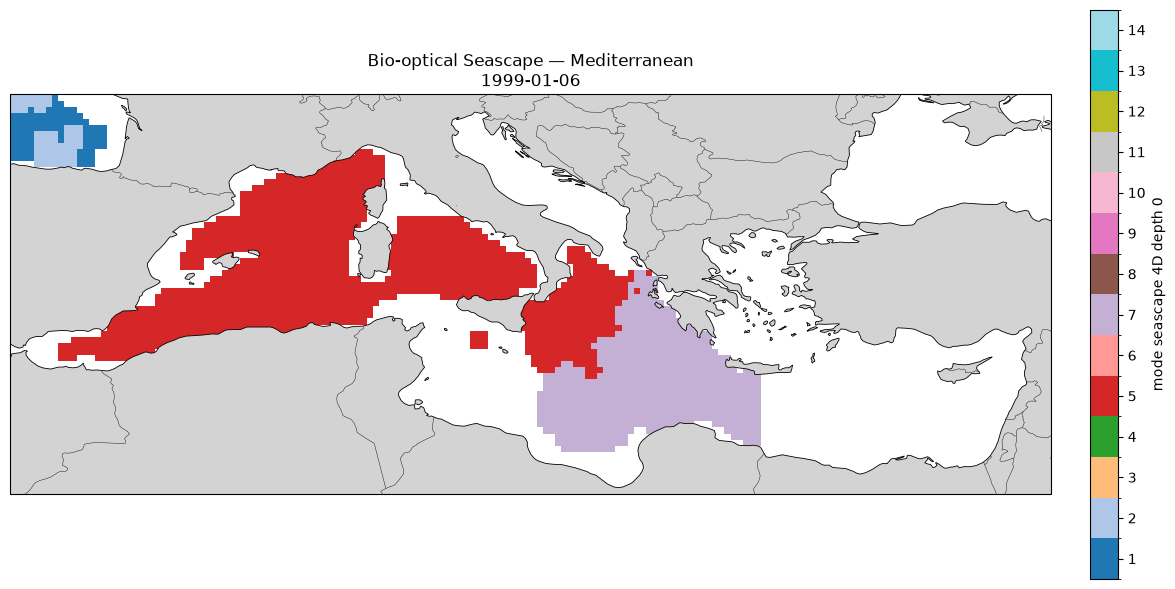

In [7]:
ds = xr.open_zarr(data_href3)

# subset data
da = ds['mode_seascape_4D'].isel(time=0, depth=0).squeeze()
da = da.rename({'longitude': 'lon', 'latitude': 'lat'})
da_plot = da.transpose("lat", "lon")

plot_med_water_class(da_plot, label="mode seascape 4D depth 0")

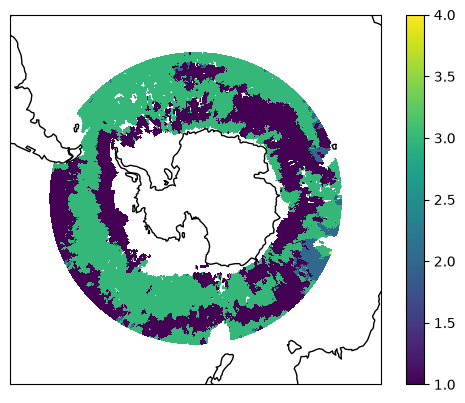

In [8]:
ds = xr.open_zarr(data_href4)

da = ds.mode_seascape_4D.isel(time=0, depth=0).transpose("latitude", "longitude")

ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())
im = ax.pcolormesh(da.longitude, da.latitude, da, transform=ccrs.PlateCarree(), shading="auto")
ax.coastlines()
plt.colorbar(im, ax=ax)
plt.show()